[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PooryaBehnamie/bioimage-analysis-notebooks/blob/main/Notebook_2B_Exercises_Solutions.ipynb)

# Notebook 2B: Exercises + Solutions
This notebook contains **worked solutions** to the exercises from Notebook 2, using the example FISH image in `data/`.

Each solution includes **code** and a short **explanation** so you can follow the reasoning. Try the exercises yourself first!

In [1]:
# --- Setup: works locally and on Google Colab ---
import sys
from pathlib import Path

if "google.colab" in sys.modules and not Path("data").exists():
    # On Colab, fetch the repository so the example data is available
    !git clone -q https://github.com/PooryaBehnamie/bioimage-analysis-notebooks.git
    %cd bioimage-analysis-notebooks

DATA_DIR = Path("data")                      # example images shipped with the repo
OUT_DIR = Path("outputs"); OUT_DIR.mkdir(exist_ok=True)   # anything we save goes here (git-ignored)

import matplotlib
matplotlib.rcParams["figure.dpi"] = 72       # keeps saved notebooks small; raise for sharper figures

import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage import io, color, img_as_float, filters, measure, segmentation

rgb_path, dapi_path = DATA_DIR / "fish_rgb.tif", DATA_DIR / "fish_dapi.tif"

### Exercise 1: Image I/O
Load the RGB and DAPI images with Matplotlib, scikit-image and OpenCV, then compare shapes, dtypes, ranges and channel order.

In [2]:
loaders = {
    "matplotlib":   lambda p: plt.imread(p),
    "scikit-image": lambda p: io.imread(p),
    "opencv":       lambda p: cv2.imread(str(p), cv2.IMREAD_UNCHANGED),
}
imgs = {}
for name, load in loaders.items():
    for kind, p in [("rgb", rgb_path), ("dapi", dapi_path)]:
        a = load(p)
        imgs[(name, kind)] = a
        print(f"{name:>12} {kind:>4}: shape={a.shape}, dtype={a.dtype}, range=({a.min()}, {a.max()})")

# Channel order: OpenCV returns BGR, so reversing its channels should match scikit-image exactly
print("\nOpenCV BGR reversed == scikit-image RGB:",
      np.array_equal(imgs[("opencv", "rgb")][..., ::-1], imgs[("scikit-image", "rgb")]))

  matplotlib  rgb: shape=(2048, 2448, 3), dtype=uint8, range=(0, 255)
  matplotlib dapi: shape=(2048, 2448), dtype=uint8, range=(0, 255)
scikit-image  rgb: shape=(2048, 2448, 3), dtype=uint8, range=(0, 255)
scikit-image dapi: shape=(2048, 2448), dtype=uint8, range=(0, 255)
      opencv  rgb: shape=(2048, 2448, 3), dtype=uint8, range=(0, 255)
      opencv dapi: shape=(2048, 2448), dtype=uint8, range=(0, 255)

OpenCV BGR reversed == scikit-image RGB: True


**Explanation:** All three loaders return the same pixel values and dtype (`uint8`) for these files. The only difference is OpenCV's **BGR** channel order. Note that `plt.imread` returns floats in `[0, 1]` for PNG files, so always check `dtype` after loading.

### Exercise 2: Arrays & dtypes
Inspect the DAPI image, convert it to `uint16` and `float`, brighten each safely, and plot histograms (inside the ROI).

Shape: (2048, 2448) | dtype: uint8 | min/max: 0 255
Brightened maxima: 255 65535 1.0


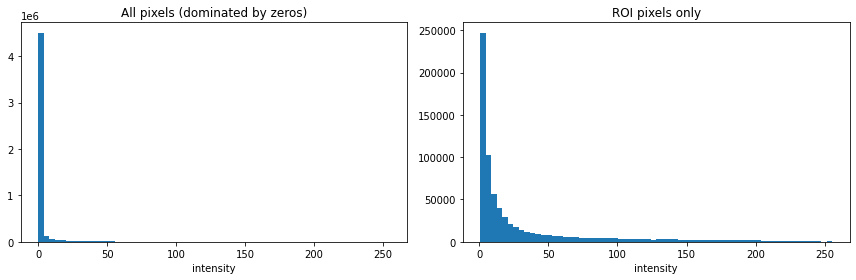

In [3]:
dapi = imgs[("scikit-image", "dapi")]
roi = dapi > 0
print("Shape:", dapi.shape, "| dtype:", dapi.dtype, "| min/max:", dapi.min(), dapi.max())

u16 = dapi.astype(np.uint16) * 257          # 0..255 -> 0..65535 (257 = 65535/255)
f   = img_as_float(dapi)                    # 0..1

# Safe brightening: do the math in a wider type, then clip back into the valid range
u8_bright  = np.clip(dapi.astype(np.int16) + 40, 0, 255).astype(np.uint8)
u16_bright = np.clip(u16.astype(np.int32) + 40 * 257, 0, 65535).astype(np.uint16)
f_bright   = np.clip(f + 40 / 255, 0, 1)
print("Brightened maxima:", u8_bright.max(), u16_bright.max(), round(f_bright.max(), 3))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].hist(dapi.ravel(), bins=64);      axs[0].set_title("All pixels (dominated by zeros)")
axs[1].hist(dapi[roi].ravel(), bins=64); axs[1].set_title("ROI pixels only")
for ax in axs: ax.set_xlabel("intensity")
plt.tight_layout(); plt.show()

**Explanation:** Adding 40 to a `uint8` pixel of 250 would wrap to 34. Converting to a wider type first and clipping avoids this. The histogram of *all* pixels is dominated by the black background outside the ROI, which hides the distribution you care about.

### Exercise 3: Color spaces
Convert to grayscale and HSV, plot H, S, V, and threshold **S** instead of V.

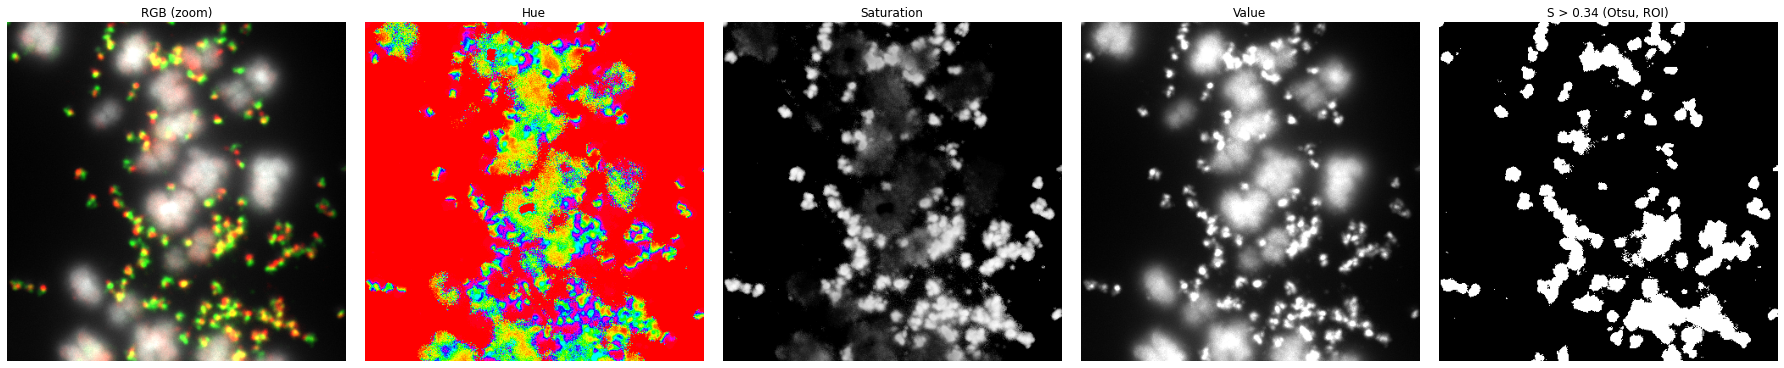

In [4]:
rgb = imgs[("scikit-image", "rgb")]
hsv = color.rgb2hsv(rgb)
H, S, V = hsv[..., 0], hsv[..., 1], hsv[..., 2]

ys, xs = slice(700, 1100), slice(1250, 1650)          # zoom window
roi_mask = dapi > 0
s_thr = filters.threshold_otsu(S[roi_mask])
s_mask = (S > s_thr) & roi_mask

fig, axs = plt.subplots(1, 5, figsize=(25, 5))
axs[0].imshow(rgb[ys, xs]);                    axs[0].set_title("RGB (zoom)")
axs[1].imshow(H[ys, xs], cmap="hsv");          axs[1].set_title("Hue")
axs[2].imshow(S[ys, xs], cmap="gray");         axs[2].set_title("Saturation")
axs[3].imshow(V[ys, xs], cmap="gray");         axs[3].set_title("Value")
axs[4].imshow(s_mask[ys, xs], cmap="gray");    axs[4].set_title(f"S > {s_thr:.2f} (Otsu, ROI)")
for ax in axs: ax.axis("off")
plt.tight_layout(); plt.show()

**Explanation:** Thresholding **V** (brightness) picks up both the bright chromosomes and the probe spots. Thresholding **S** (saturation) favors the **colored probe spots**, because gray has near-zero saturation. It is not a perfect separator, though. The chromosomes in this composite are slightly tinted by nearby probe light, so the S mask also includes hazy regions around spot clusters. Subtracting the blue channel (Notebook 2) isolates the probes more cleanly. Hue is noisy wherever saturation is low, since the color of a gray pixel is undefined.

### Exercise 4: Masking & overlays
Create an Otsu mask from DAPI, apply it with NumPy and OpenCV, and draw the mask outline on the RGB image.

NumPy and OpenCV masking identical: True


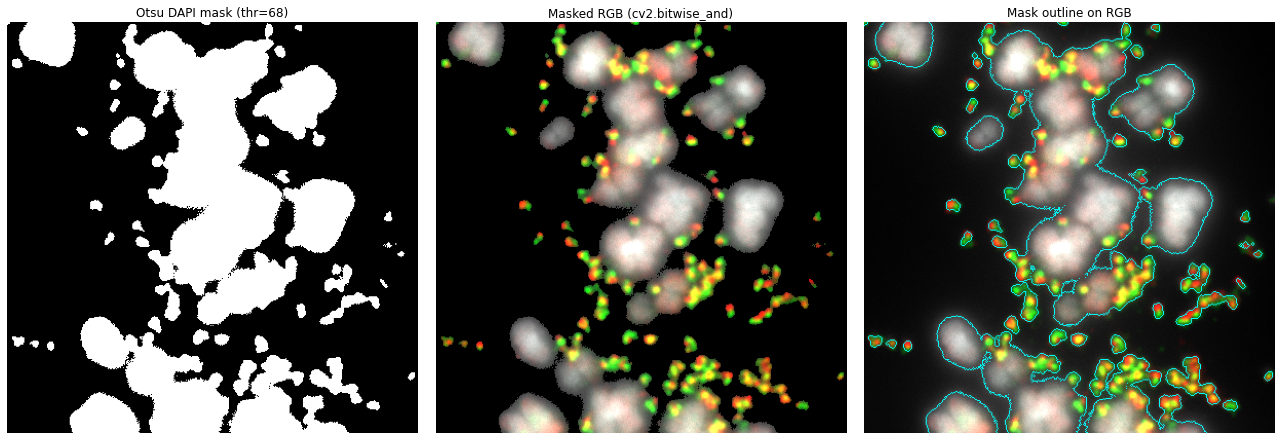

In [5]:
thr = filters.threshold_otsu(dapi)
mask = dapi > thr

masked_np = rgb.copy(); masked_np[~mask] = 0                                  # NumPy
masked_cv = cv2.bitwise_and(rgb, rgb, mask=(mask * 255).astype(np.uint8))      # OpenCV
print("NumPy and OpenCV masking identical:", np.array_equal(masked_np, masked_cv))

outline = segmentation.mark_boundaries(rgb[ys, xs], mask[ys, xs], color=(0, 1, 1))

fig, axs = plt.subplots(1, 3, figsize=(18, 6))
axs[0].imshow(mask[ys, xs], cmap="gray"); axs[0].set_title(f"Otsu DAPI mask (thr={thr:.0f})")
axs[1].imshow(masked_cv[ys, xs]);         axs[1].set_title("Masked RGB (cv2.bitwise_and)")
axs[2].imshow(outline);                   axs[2].set_title("Mask outline on RGB")
for ax in axs: ax.axis("off")
plt.tight_layout(); plt.show()

**Explanation:** Both methods give identical results. The outline makes the problem from Notebook 2 visible: the Otsu DAPI mask hugs the chromosomes and cuts off many of the probe spots between them.

### Exercise 5: Connected components
Detect **red (ERBB2)** and **green (MYC)** spots separately, compare OpenCV and scikit-image, and filter small blobs.

ERBB2 (red): OpenCV 415 objects, scikit-image 415 objects, same areas: True, kept >= 10px: 286
MYC (green): OpenCV 351 objects, scikit-image 351 objects, same areas: True, kept >= 10px: 294


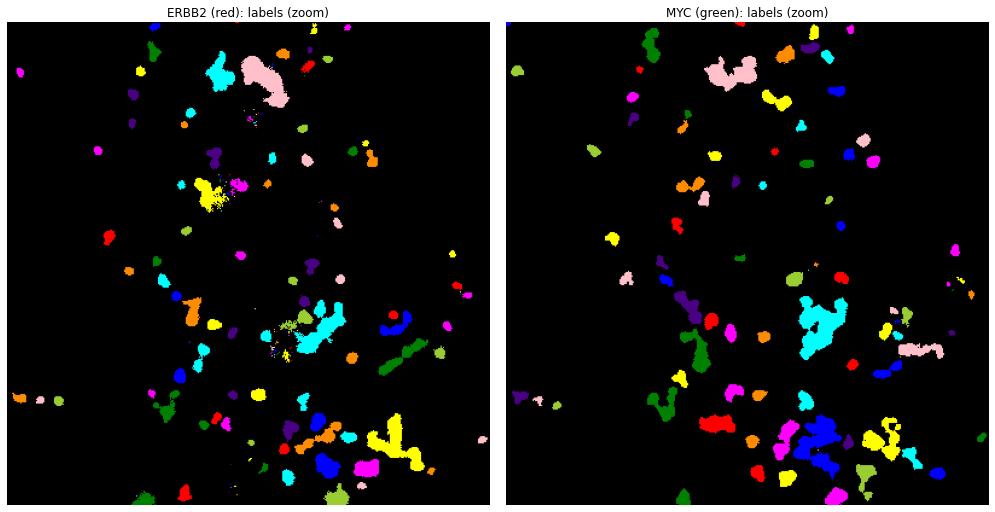

In [6]:
rgb16 = rgb.astype(np.int16)
channels = {
    "ERBB2 (red)":  np.clip(rgb16[..., 0] - rgb16[..., 2], 0, 255).astype(np.uint8),
    "MYC (green)":  np.clip(rgb16[..., 1] - rgb16[..., 2], 0, 255).astype(np.uint8),
}
min_area = 10
fig, axs = plt.subplots(1, 2, figsize=(14, 7))
for ax, (name, sig) in zip(axs, channels.items()):
    t = filters.threshold_otsu(sig[roi_mask])
    binary = ((sig > t) & roi_mask).astype(np.uint8)

    n_cv, lab_cv, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    lab_sk = measure.label(binary, connectivity=2)
    areas_sk = np.array([p.area for p in measure.regionprops(lab_sk)])
    areas_cv = stats[1:, cv2.CC_STAT_AREA]

    kept = (areas_sk >= min_area).sum()
    print(f"{name}: OpenCV {n_cv - 1} objects, scikit-image {lab_sk.max()} objects, "
          f"same areas: {np.array_equal(np.sort(areas_cv), np.sort(areas_sk))}, kept >= {min_area}px: {kept}")

    ax.imshow(color.label2rgb(lab_sk[ys, xs], bg_label=0)); ax.set_title(f"{name}: labels (zoom)"); ax.axis("off")
plt.tight_layout(); plt.show()

**Explanation:** With the same connectivity (8-connected in OpenCV = `connectivity=2` in scikit-image), both libraries find exactly the same objects. Splitting by probe avoids merging a touching red and green spot into one object, but spots of the *same* color that touch will still merge. Watershed and LoG (Notebook 3) address that.

---

### Acknowledgements

This notebook was prepared with the assistance of AI tools (ChatGPT, Grok, Gemini and Claude), which were used to help draft, edit, test and refine the code and explanatory text. Final responsibility for scientific accuracy, structure and educational content rests with the author.

Example FISH data: Brunk Lab, [ecEnhance](https://github.com/Brunk-Lab/ecEnhance) repository (MIT License).